In [1]:
"""
Cell 1: Data Preparation & Dropping Identifiers
We load the rich dataset from Phase 3, isolate our target variable (y), and drop any non-predictive identifiers from our feature matrix (X).
"""

# Cell 1
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# Define paths
ADVANCED_FEATURES_PATH = '../data/processed/advanced_features_and_churn.parquet'

print("Loading modeling dataset...")
df = pd.read_parquet(ADVANCED_FEATURES_PATH)

# Define Target (y) and Features (X)
y = df['Churn']

# Drop the ID (model shouldn't memorize users) and the target
X = df.drop(columns=['CustomerID', 'Churn'])

# Ensure only numeric columns are left (in case any dates slipped through)
X = X.select_dtypes(include=[np.number])

print(f"Feature Matrix (X) Shape: {X.shape}")
print(f"Target Vector (y) Shape: {y.shape}")
display(X.head())

Loading modeling dataset...
Feature Matrix (X) Shape: (3370, 7)
Target Vector (y) Shape: (3370,)


,Recency,Frequency,Monetary,Tenure,Velocity,AOV,ItemDiversity
0,235,1,77183.60,235,235.000000,77183.600000,1
1,39,5,2790.86,277,55.400000,558.172000,82
2,158,3,1487.24,268,89.333333,495.746667,22
3,220,1,334.40,220,220.000000,334.400000,17
4,172,5,1561.81,206,41.200000,312.362000,26


In [2]:
"""
Cell 2: Train-Test Split and Feature Scaling
To prevent data leakage during training, we split the data 80/20.
Important: Logistic Regression is highly sensitive to the scale of the data (e.g., Monetary is in thousands, Frequency is in single digits). We must standardize the features so the baseline model works correctly. Tree-based models (XGBoost) don't care about scale, but scaling won't hurt them.
"""

# Cell 2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Split the data (80% training, 20% testing)
# We use stratify=y to ensure the 43% churn rate is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Scale the features for Logistic Regression
scaler = StandardScaler()

# Fit ONLY on training data to prevent leakage, then transform both
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"Training samples: {len(X_train_scaled)}")
print(f"Testing samples: {len(X_test_scaled)}")

Training samples: 2696
Testing samples: 674


In [3]:
"""
Cell 3: Training the Models (The Arena)
Here, we pit our simple baseline against the heavyweights.

"""
# Cell 3
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("Training models...")

# 1. The Baseline: Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
print("Logistic Regression trained.")

# 2. The Heavyweight: XGBoost
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)
print("XGBoost trained.")

# 3. The Speedster: LightGBM
lgb_model = LGBMClassifier(random_state=42)
lgb_model.fit(X_train_scaled, y_train)
print("LightGBM trained.")


Training models...
Logistic Regression trained.
XGBoost trained.
[LightGBM] [Info] Number of positive: 1159, number of negative: 1537
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1375
[LightGBM] [Info] Number of data points in the train set: 2696, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.429896 -> initscore=-0.282275
[LightGBM] [Info] Start training from score -0.282275
LightGBM trained.


In [4]:
"""
Cell 4: Evaluation and Comparison
We will look at the ROC-AUC score (how well it separates churners from non-churners) and the Classification Report (which shows Precision and Recall).
"""

# Cell 4
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "Logistic Regression (Baseline)": lr_model,
    "XGBoost": xgb_model,
    "LightGBM": lgb_model
}

for name, model in models.items():
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] # Get probabilities for AUC
    
    # Calculate metrics
    auc_score = roc_auc_score(y_test, y_proba)
    
    # Print results
    print(f"--- {name} ---")
    print(f"ROC-AUC Score: {auc_score:.4f}")
    print(classification_report(y_test, y_pred))
    print("\n")

--- Logistic Regression (Baseline) ---
ROC-AUC Score: 0.7237
              precision    recall  f1-score   support

           0       0.73      0.70      0.71       384
           1       0.62      0.65      0.64       290

    accuracy                           0.68       674
   macro avg       0.67      0.67      0.67       674
weighted avg       0.68      0.68      0.68       674



--- XGBoost ---
ROC-AUC Score: 0.6764
              precision    recall  f1-score   support

           0       0.68      0.67      0.68       384
           1       0.57      0.58      0.57       290

    accuracy                           0.63       674
   macro avg       0.62      0.63      0.63       674
weighted avg       0.63      0.63      0.63       674



--- LightGBM ---
ROC-AUC Score: 0.6952
              precision    recall  f1-score   support

           0       0.70      0.66      0.68       384
           1       0.58      0.63      0.61       290

    accuracy                           0

Extracting insights from the Champion Model (Logistic Regression)...


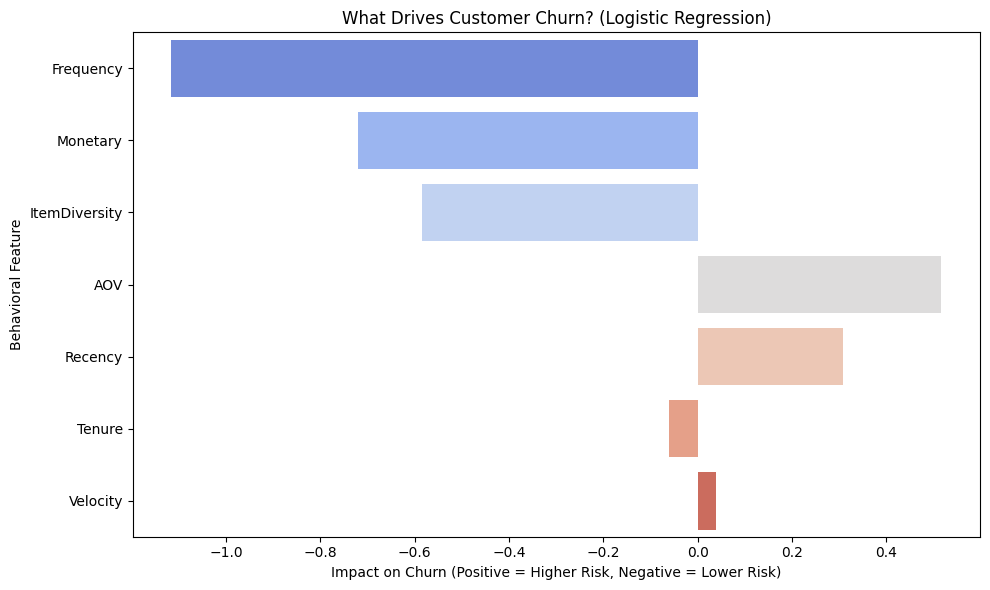

In [5]:
# Cell 5: Extracting Business Insights (LR Coefficients)

# Cell 5
import matplotlib.pyplot as plt
import seaborn as sns

print("Extracting insights from the Champion Model (Logistic Regression)...")

# Extract coefficients from Logistic Regression
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lr_model.coef_[0]
})

# Sort by absolute value to see the strongest drivers (whether positive or negative)
feature_importance = feature_importance.sort_values(by='Importance', key=abs, ascending=False)

# Plot it
plt.figure(figsize=(10, 6))
# Using a diverging palette to show positive vs negative impact
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='coolwarm')
plt.title('What Drives Customer Churn? (Logistic Regression)')
plt.xlabel('Impact on Churn (Positive = Higher Risk, Negative = Lower Risk)')
plt.ylabel('Behavioral Feature')
plt.tight_layout()
plt.show()

In [ ]:
#Cell 6: Saving the Champion Model
# We will save the lr_model instead of the xgb_model

# Cell 6
import joblib
import os

# Ensure models directory exists
os.makedirs('../models/churn', exist_ok=True)

# Save the Logistic Regression model and the Scaler
joblib.dump(lr_model, '../models/churn/lr_champion.pkl')
joblib.dump(scaler, '../models/churn/feature_scaler.pkl')

print("Champion LR model and Scaler successfully saved to production folder!")

Champion LR model and Scaler successfully saved to production folder!


: 